#Feature Extraction & Sentiment Scoring

In [19]:
# Mounting Google Drive to access the dataset
import numpy as np
import pandas as pd
path = "dataset.csv"
df = pd.read_csv(path)


C:\Users\hafiz\AppData\Local\Temp\ipykernel_16400\1358412839.py:5: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


In [20]:
# Importing necessary libraries for data handling and NLP
import pandas as pd
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Downloading essential NLTK resources
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [21]:
# Loading the COVID-19 Twitter dataset from CSV
df = pd.read_csv(path)

# Creating a small sample for faster processing during the tutorial
df_sample = df.head(2000).copy()

C:\Users\hafiz\AppData\Local\Temp\ipykernel_16400\3790811478.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


In [22]:
# Step 1: Noise Removal
# Removing URLs, Twitter handles (@user), and non-textual clutter
def clean_noise(text):
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # Remove URLs
    text = re.sub(r'@\w+', '', text) # Remove @mentions
    text = re.sub(r'#\w+', '', text) # Remove hashtags if desired (optional)
    return text

df_sample['clean_text'] = df_sample['TWEET'].apply(clean_noise)

In [23]:
# Step 2: Case Filtering (Normalization)
# Converting all text to lowercase to ensure consistency
df_sample['clean_text'] = df_sample['clean_text'].str.lower()

In [24]:
# Step 3: Tokenization
# Breaking the text strings into individual words (tokens)
df_sample['tokens'] = df_sample['clean_text'].apply(word_tokenize)

In [25]:
# Step 4: Punctuation & Special Character Removal
# Filtering out tokens that are purely punctuation marks
df_sample['tokens'] = df_sample['tokens'].apply(lambda x: [word for word in x if word.isalnum()])

In [26]:
# Step 5: Stop Word Removal
# We combine the standard NLTK list with custom 'dictionary' of noise words

# 1. Load the standard English stopwords
stop_words = set(stopwords.words('english'))

# 2. Add your custom stopwords
custom_stopwords = ['co', 'covid', 'coronavirus', 'amp', 'rt']
stop_words.update(custom_stopwords)

# 3. Apply the removal to the tokens
df_sample['tokens'] = df_sample['tokens'].apply(lambda x: [word for word in x if word not in stop_words])

# Optional: Verify the list of words being removed
print(f"Total stopwords being filtered: {len(stop_words)}")

Total stopwords being filtered: 203


In [27]:
# Step 6: Lemmatization
# Reducing words to their dictionary root form (e.g., 'hospitals' -> 'hospital')
# This is crucial for matching words in the AFINN and TextBlob dictionaries.
lemmatizer = WordNetLemmatizer()

df_sample['lemmatized_tokens'] = df_sample['tokens'].apply(lambda x: [lemmatizer.lemmatize(word) for word in x])

In [28]:
# Previewing the transformation from raw text to lemmatized tokens
df_sample[['TWEET', 'lemmatized_tokens']].head()

,TWEET,lemmatized_tokens
0,RT @robertoglezcano: @amazon #Patents Show Fl...,"[show, flying, warehouse, send, delivery, dron..."
1,Amazon,[amazon]
2,@FAME95FM1 Jamaicans make money with @Payoneer...,"[jamaican, make, money]"
3,@CBSi Jamaicans make money with @Payoneer @Pay...,"[jamaican, make, money]"
4,@Hitz92fm Jamaicans make money with @Payoneer ...,"[jamaican, make, money]"


---
## Approach 1: Term Frequency - Inverse Document Frequency (TF-IDF)
**Objective:** To convert our cleaned text into numerical weights to find the most "important" words in the dataset, filtering out noise.

In [29]:
# Step 1: Calculate TF-IDF & Extract Keywords with Scores ---
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# Join tokens back into a string as required by the TfidfVectorizer
# This uses the lemmatized versions to ensure word consistency
df_sample['joined_tokens'] = df_sample['lemmatized_tokens'].apply(lambda x: ' '.join(x))

# Initialize the Vectorizer and limit the vocabulary to the top 1000 features
tfidf_vectorizer = TfidfVectorizer(max_features=1000)
tfidf_matrix = tfidf_vectorizer.fit_transform(df_sample['joined_tokens'])

# Create a Weights DataFrame to hold the importance score for every word
feature_names = tfidf_vectorizer.get_feature_names_out()
df_tfidf = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)

# Function to identify 'Top N' words and their specific numerical weights
def get_top_keywords_with_scores(row_index, df_tfidf, n_top=3):
    row = df_tfidf.iloc[row_index]
    # Sort weights descending and filter for words that were actually present
    top_words = row.sort_values(ascending=False).head(n_top)
    top_words = top_words[top_words > 0]

    # Return a formatted string: "word (score)"
    return ", ".join([f"{word} ({score:.2f})" for word, score in top_words.items()])

# Apply the function to the sample dataset to create the keywords column
df_sample['tfidf_keywords'] = [get_top_keywords_with_scores(i, df_tfidf) for i in range(len(df_sample))]

print("✅ TF-IDF Matrix Generated and Keywords with Scores Extracted!")

# Preview the results
df_sample[['text', 'tfidf_keywords']].head(10)

✅ TF-IDF Matrix Generated and Keywords with Scores Extracted!


KeyError: "['text'] not in index"

In [ ]:
# Step 2: Generate Global Sparse Matrix ---

# 1. Extract the actual words (feature names) from the vectorizer
feature_names = tfidf_vectorizer.get_feature_names_out()

# 2. Convert the numerical matrix into a readable Pandas DataFrame
# Each row = one tweet, each column = one word
df_tfidf = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)

print(f"✅ Global Sparse Matrix Created!")
print(f"Total Tweets (Rows): {df_tfidf.shape[0]}")
print(f"Total Vocabulary (Columns): {df_tfidf.shape[1]}")

# 3. Preview a small 'slice' of the matrix
# We show the first 5 tweets and 10 words to see the 0.0 values (Sparsity)
df_tfidf.iloc[:5, 100:110]

✅ Global Sparse Matrix Created!
Total Tweets (Rows): 2000
Total Vocabulary (Columns): 1000


,based,battle,beach,beat,beautiful,become,bed,begin,beginning,believe
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


The table you see after running the TF-IDF code is called a Sparse Matrix. It is essentially a mathematical "map" that tells the computer how much weight each word carries in every single tweet. A high value means the word is very important to that specific tweet but relatively rare in the rest of the dataset. Minimum value: 0.0, Maximum value: 1.0

/tmp/ipykernel_9190/316762353.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_20_tfidf_words.values, y=top_20_tfidf_words.index, palette='magma')


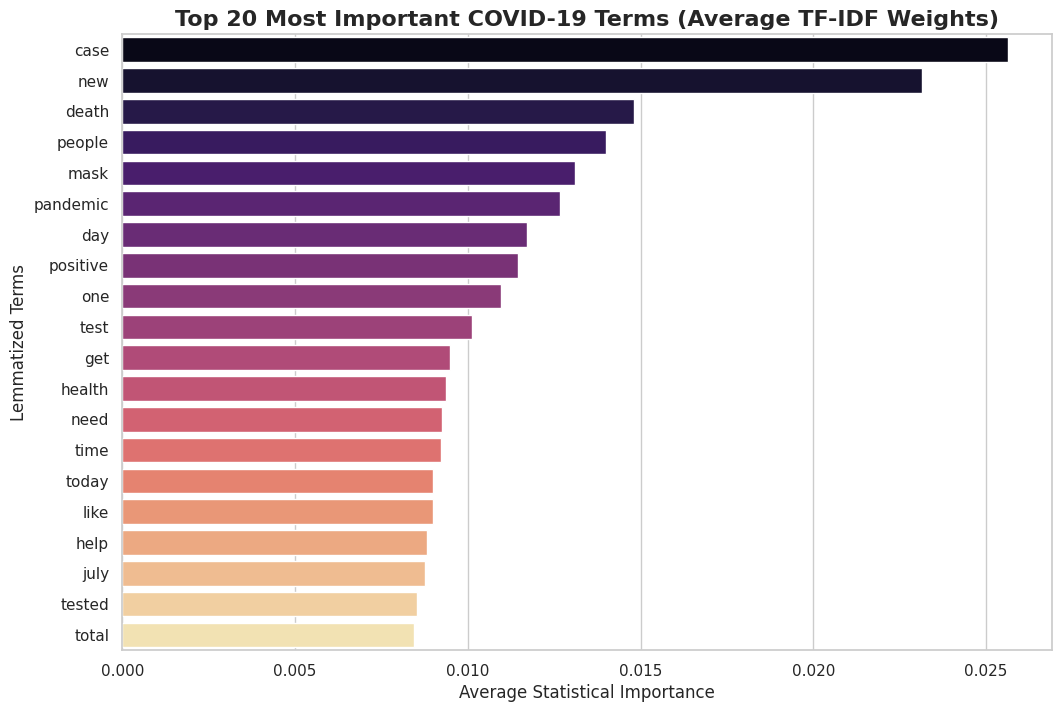

In [ ]:
# Step 3: Visualizing Average Importance ---
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the average weight for every word across all 2,000 tweets
# We use .mean() on the matrix we created in the previous step
average_tfidf_weights = df_tfidf.mean().sort_values(ascending=False)

# 2. Grab the top 20 words
top_20_tfidf_words = average_tfidf_weights.head(20)

# 3. Create the Visualization
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# Create a horizontal bar chart
sns.barplot(x=top_20_tfidf_words.values, y=top_20_tfidf_words.index, palette='magma')

# Add academic titles and axis labels
plt.title("Top 20 Most Important COVID-19 Terms (Average TF-IDF Weights)", fontsize=16, fontweight='bold')
plt.xlabel("Average Statistical Importance", fontsize=12)
plt.ylabel("Lemmatized Terms", fontsize=12)

plt.show()

---
## Approach 2: Sentiment Analysis using TextBlob
**Objective:** To classify the emotional tone of the tweets into Positive, Negative, or Neutral categories using predefined linguistic patterns.

In [ ]:
# Step 1: Initialize TextBlob and Calculate Polarity
from textblob import TextBlob

# We define a function to get the polarity score (-1 to 1)
def get_textblob_polarity(text):
    return TextBlob(text).sentiment.polarity

# Apply the function to our joined clean strings
df_sample['textblob_polarity'] = df_sample['joined_tokens'].apply(get_textblob_polarity)

In [ ]:
# Step 2: Categorize the scores into 3 Sentiment Classes
def get_sentiment_class(score):
    if score > 0:
        return 'Positive'
    elif score < 0:
        return 'Negative'
    else:
        return 'Neutral'

df_sample['textblob_sentiment'] = df_sample['textblob_polarity'].apply(get_sentiment_class)

# Preview the results
print("✅ TextBlob Sentiment Analysis Complete!")
df_sample[['TWEET', 'textblob_polarity', 'textblob_sentiment']].head(10)

✅ TextBlob Sentiment Analysis Complete!


,text,textblob_polarity,textblob_sentiment
0,If I smelled the scent of hand sanitizers toda...,-0.25,Negative
1,Hey @Yankees @YankeesPR and @MLB - wouldn't it...,0.00,Neutral
2,@diane3443 @wdunlap @realDonaldTrump Trump nev...,0.00,Neutral
3,@brookbanktv The one gift #COVID19 has give me...,0.00,Neutral
4,25 July : Media Bulletin on Novel #CoronaVirus...,0.00,Neutral
5,#coronavirus #covid19 deaths continue to rise....,-0.70,Negative
6,How #COVID19 Will Change Work in General (and ...,0.05,Positive
7,You now have to wear face coverings when out s...,0.00,Neutral
8,Praying for good health and recovery of @Chouh...,0.70,Positive
9,POPE AS GOD - Prophet Sadhu Sundar Selvaraj. W...,0.00,Neutral


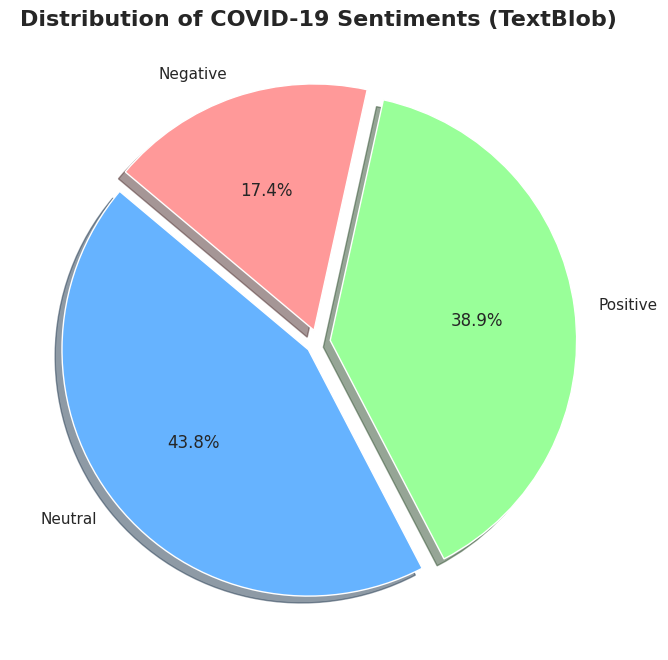

In [ ]:
# Step 3: Visualize Sentiment Distribution using a Pie Chart
# Counting the number of tweets in each category
sentiment_counts = df_sample['textblob_sentiment'].value_counts()

# Set up the pie chart
plt.figure(figsize=(8, 8))
colors = ['#66b3ff', '#99ff99', '#ff9999'] # Blue for Neutral, Green for Positive, Red for Negative

plt.pie(sentiment_counts,
        labels=sentiment_counts.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=colors,
        explode=(0.05, 0.05, 0.05), # Slightly separates the slices
        shadow=True)

plt.title("Distribution of COVID-19 Sentiments (TextBlob)", fontsize=16, fontweight='bold')
plt.show()

---
## Approach 3: Sentiment Analysis using AFINN
**Objective:** To calculate sentiment using a manually curated lexicon of over 2,400 English words, each assigned an integer score between -5 (negative) and +5 (positive).

In [ ]:
# Step 1: Install and Initialize AFINN
!pip install afinn
from afinn import Afinn

# Initialize the AFINN scorer
afinn = Afinn()


In [ ]:
# Step 2: Calculate AFINN Scores
# We apply the score function to our joined clean strings
df_sample['afinn_score'] = df_sample['joined_tokens'].apply(afinn.score)


In [ ]:
# Step 3: Categorize the scores into 3 Sentiment Classes
# Note: Since AFINN results are integers, 0 is strictly Neutral
def get_afinn_class(score):
    if score > 0:
        return 'Positive'
    elif score < 0:
        return 'Negative'
    else:
        return 'Neutral'

df_sample['afinn_sentiment'] = df_sample['afinn_score'].apply(get_afinn_class)

# Preview the results
print("✅ AFINN Sentiment Analysis Complete!")
df_sample[['TWEET', 'afinn_score', 'afinn_sentiment']].head(10)

✅ AFINN Sentiment Analysis Complete!


,text,afinn_score,afinn_sentiment
0,If I smelled the scent of hand sanitizers toda...,0.0,Neutral
1,Hey @Yankees @YankeesPR and @MLB - wouldn't it...,1.0,Positive
2,@diane3443 @wdunlap @realDonaldTrump Trump nev...,-2.0,Negative
3,@brookbanktv The one gift #COVID19 has give me...,4.0,Positive
4,25 July : Media Bulletin on Novel #CoronaVirus...,2.0,Positive
5,#coronavirus #covid19 deaths continue to rise....,-4.0,Negative
6,How #COVID19 Will Change Work in General (and ...,0.0,Neutral
7,You now have to wear face coverings when out s...,0.0,Neutral
8,Praying for good health and recovery of @Chouh...,4.0,Positive
9,POPE AS GOD - Prophet Sadhu Sundar Selvaraj. W...,1.0,Positive


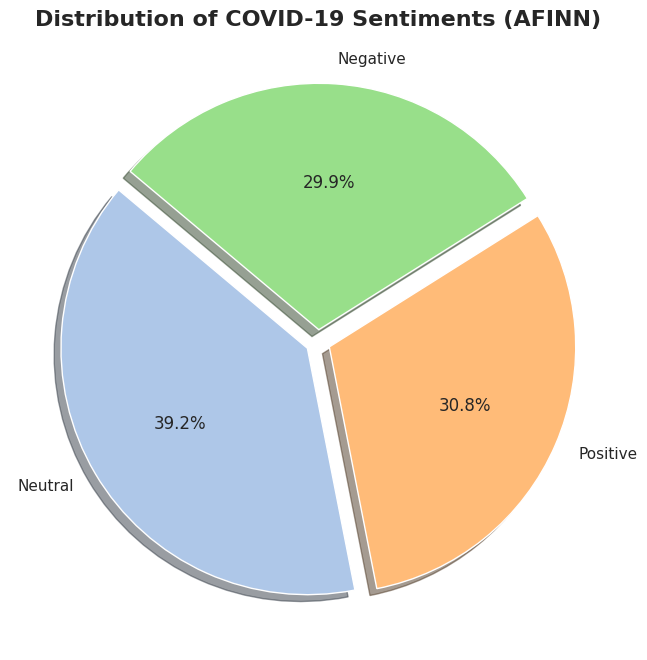

In [ ]:
# Step 4: Visualize AFINN Sentiment Distribution
afinn_counts = df_sample['afinn_sentiment'].value_counts()

plt.figure(figsize=(8, 8))
# Using a different color palette to distinguish from TextBlob
colors = ['#aec7e8', '#ffbb78', '#98df8a']

plt.pie(afinn_counts,
        labels=afinn_counts.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=colors,
        explode=(0.05, 0.05, 0.05),
        shadow=True)

plt.title("Distribution of COVID-19 Sentiments (AFINN)", fontsize=16, fontweight='bold')
plt.show()

In [ ]:
# Comparison Table
# Let's look at the top words (TF-IDF) alongside the two sentiment scores
print("--- Final Comparison of All Three Approaches ---")
comparison_columns = ['text', 'textblob_sentiment', 'afinn_sentiment']
df_sample[comparison_columns].head(15)

--- Final Comparison of All Three Approaches ---


,text,textblob_sentiment,afinn_sentiment
0,If I smelled the scent of hand sanitizers toda...,Negative,Neutral
1,Hey @Yankees @YankeesPR and @MLB - wouldn't it...,Neutral,Positive
2,@diane3443 @wdunlap @realDonaldTrump Trump nev...,Neutral,Negative
3,@brookbanktv The one gift #COVID19 has give me...,Neutral,Positive
4,25 July : Media Bulletin on Novel #CoronaVirus...,Neutral,Positive
5,#coronavirus #covid19 deaths continue to rise....,Negative,Negative
6,How #COVID19 Will Change Work in General (and ...,Positive,Neutral
7,You now have to wear face coverings when out s...,Neutral,Neutral
8,Praying for good health and recovery of @Chouh...,Positive,Positive
9,POPE AS GOD - Prophet Sadhu Sundar Selvaraj. W...,Neutral,Positive


---
## Final Comparison of Approaches
**Objective:** To compare the results of TF-IDF (Topic Importance), TextBlob (Pattern-based Sentiment), and AFINN (Lexicon-based Sentiment) in a single unified view.

In [ ]:
# --- Final Comparison Table ---

# Define the columns we want to compare
# 'text' = Raw tweet
# 'tfidf_keywords' = The core topics identified by math
# 'textblob_sentiment' = Sentiment based on linguistic patterns
# 'afinn_sentiment' = Sentiment based on integer word sums
comparison_columns = ['text', 'tfidf_keywords', 'textblob_sentiment', 'afinn_sentiment']

# Display the top 15 rows for analysis
print("--- Side-by-Side Method Comparison ---")
display(df_sample[comparison_columns].head(15))

# Quick Summary: How much do the two sentiment methods agree?
# This is a great 'bonus' metric for students to see
agreement = (df_sample['textblob_sentiment'] == df_sample['afinn_sentiment']).sum()
agreement_pct = (agreement / len(df_sample)) * 100

print(f"\n--- Summary Statistics ---")
print(f"Total Tweets Analyzed: {len(df_sample)}")
print(f"Sentiment Agreement: {agreement_pct:.1f}% of tweets received the same class from both methods.")

--- Side-by-Side Method Comparison ---


,text,tfidf_keywords,textblob_sentiment,afinn_sentiment
0,If I smelled the scent of hand sanitizers toda...,"past (0.47), someone (0.44), think (0.41)",Negative,Neutral
1,Hey @Yankees @YankeesPR and @MLB - wouldn't it...,"hey (0.44), player (0.43), sense (0.43)",Neutral,Positive
2,@diane3443 @wdunlap @realDonaldTrump Trump nev...,"effort (0.54), claim (0.54), never (0.50)",Neutral,Negative
3,@brookbanktv The one gift #COVID19 has give me...,"always (0.50), around (0.46), give (0.46)",Neutral,Positive
4,25 July : Media Bulletin on Novel #CoronaVirus...,"medium (0.57), novel (0.54), 25 (0.46)",Neutral,Positive
5,#coronavirus #covid19 deaths continue to rise....,"continue (0.40), politician (0.40), almost (0.39)",Negative,Negative
6,How #COVID19 Will Change Work in General (and ...,"general (0.65), change (0.58), work (0.50)",Positive,Neutral
7,You now have to wear face coverings when out s...,"covering (0.48), visit (0.43), community (0.42)",Neutral,Neutral
8,Praying for good health and recovery of @Chouh...,"recovery (0.61), good (0.59), health (0.53)",Positive,Positive
9,POPE AS GOD - Prophet Sadhu Sundar Selvaraj. W...,"god (0.73), watch (0.68)",Neutral,Positive



--- Summary Statistics ---
Total Tweets Analyzed: 2000
Sentiment Agreement: 51.8% of tweets received the same class from both methods.
